# Diffusion model to generate new images


This notebook contains a complete PyTorch implementation of a Denoising Diffusion Probabilistic Model (DDPM) trained on the MNIST dataset using a U-Net architectural setting. It includes support for different noise schedules, visualization utilities, and hyperparameter optimization via Optuna.

Installing packages

In [8]:
import torch
import torchvision
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
import matplotlib.pyplot as plt
import optuna




### Defining the Diffusion Trainer class

In [11]:


class DiffusionTrainer:
    """
    DiffusionTrainer is class encapsulating the training and sampling procedures of a Denoising Diffusion Probabilistic Model (DDPM).

    This class implements:
    - Forward diffusion process using a noise scheduler (q(x_t | x_0))
    - Training of a UNet neural network to predict added noise at any timestep
    - Sampling procedure from pure noise using the learned denoising model

    Attributes:
        model: The UNet2DModel that predicts noise from noised inputs
        noise_scheduler: A scheduler managing noise levels at each timestep
        optimizer: Optimizer for model training
        device: Device on which model and data are placed
    """
    def __init__(self, device, scheduler_kwargs=None, lr=1e-4):
        """
        Initialize the trainer with model, scheduler, and optimizer.

        Args:
            device: Torch device ("cuda" or "cpu")
            scheduler_kwargs: Dictionary of keyword arguments to customize the DDPMScheduler.
                Accepts keys such as:
                    - beta_schedule (str): e.g., "linear", "scaled_linear", "squaredcos_cap_v2"
                    - beta_start (float): Initial beta value for linear schedules
                    - beta_end (float): Final beta value for linear schedules
                    - num_train_timesteps (int): Total number of diffusion steps
                    - lr: Learning rate for the optimizer
        """
        self.device = device
        self.dir = dir
        self.model = UNet2DModel(
            sample_size=28,
            in_channels=1,
            out_channels=1,
            layers_per_block=2,
            block_out_channels=(32, 64, 128),
            down_block_types=("DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D"),
            up_block_types=("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
        ).to(device)

        if scheduler_kwargs is None:
            scheduler_kwargs = {
                "beta_schedule": "squaredcos_cap_v2",
                "num_train_timesteps": 1000
            }

        self.noise_scheduler = DDPMScheduler(**scheduler_kwargs)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

    def train(self, dataloader, epochs):
        """
        Train the diffusion model to predict noise added during forward process.

        Args:
            dataloader: DataLoader providing training batches of clean images
            epochs: Number of passes through the training dataset
        """
        self.model.train()
        losses = []
        for epoch in range(epochs):
            epoch_losses = []
            for batch, _ in dataloader:
                batch = batch.to(self.device)
                timesteps = torch.randint(
                    0, self.noise_scheduler.num_train_timesteps,
                    (batch.size(0),), device=self.device
                ).long()

                noise = torch.randn_like(batch)
                noisy_batch = self.noise_scheduler.add_noise(batch, noise, timesteps)

                noise_pred = self.model(noisy_batch, timesteps).sample
                loss = nn.functional.mse_loss(noise_pred, noise)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                epoch_losses.append(loss.item())

            avg_loss = sum(epoch_losses) / len(epoch_losses)
            losses.append(avg_loss)
            print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {avg_loss:.5f}")

        torch.save(
                self.model.state_dict(),
                f"{epoch+1}ep_{self.noise_scheduler.config.beta_schedule}_number_generator.pt"
            )

        plt.figure(figsize=(10, 5))
        plt.plot(losses)
        plt.title("Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.show()

    def sample(self, num_samples=16):
        """
        Generates images by reversing the diffusion process starting from Gaussian noise.

        Args:
            num_samples: Number of images to generate

        Returns:
            A batch of generated images scaled to [0, 1] for visualization
        """
        self.model.eval()
        img = torch.randn(num_samples, 1, 28, 28, device=self.device)
        for t in self.noise_scheduler.timesteps:
            with torch.no_grad():
                pred_noise = self.model(img, t).sample
            img = self.noise_scheduler.step(pred_noise, t, img).prev_sample

        img = (img.clamp(-1, 1) + 1) / 2
        return img


def objective(trial):
    """
    Optuna objective function for hyperparameter tuning of the DDPM.
    Tunes the beta_schedule, beta_start, beta_end, and learning rate.
    """
    scheduler_params = {
        "beta_schedule": trial.suggest_categorical("beta_schedule", ["linear", "scaled_linear", "squaredcos_cap_v2", "sigmoid"]),
        "beta_start": trial.suggest_float("beta_start", 1e-5, 1e-3, log=True),
        "beta_end": trial.suggest_float("beta_end", 0.01, 0.2),
        "num_train_timesteps": 1000
    }
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)

    trainer = DiffusionTrainer(device=device, scheduler_kwargs=scheduler_params, lr=lr)
    trainer.model.train()

    losses = []
    for batch, _ in train_dataloader:
        batch = batch.to(device)
        timesteps = torch.randint(0, trainer.noise_scheduler.num_train_timesteps, (batch.size(0),), device=device).long()
        noise = torch.randn_like(batch)
        noisy_batch = trainer.noise_scheduler.add_noise(batch, noise, timesteps)
        noise_pred = trainer.model(noisy_batch, timesteps).sample
        loss = nn.functional.mse_loss(noise_pred, noise)

        trainer.optimizer.zero_grad()
        loss.backward()
        trainer.optimizer.step()

        losses.append(loss.item())
        if len(losses) > 10:
            break

    return sum(losses) / len(losses)

def plot_noise(scheduler_kwargs=None):
    """
    Visualizes the schedule of noise accumulation used by the DDPMScheduler.

    Args:
    scheduler_kwargs (dict, optional): Dictionary of parameters to configure the noise scheduler.
        If None, default scheduler settings will be used.
    """
    if scheduler_kwargs is None:
        scheduler_kwargs = {}
    noise_scheduler = DDPMScheduler(**scheduler_kwargs)
    schedule_name = scheduler_kwargs.get("beta_schedule", "Unknown Schedule")

    plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"$\sqrt{\bar{\alpha}_t}$")

    plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{1 - \bar{\alpha}_t}$")

    plt.xlabel('Time step')
    plt.ylabel('Value')
    if schedule_name:
        plt.title(f'Noise Scheduler Parameters with {schedule_name}')
    else:
        plt.title('Noise Scheduler Parameters')
    plt.legend(fontsize="x-large")
    plt.show()

def plot_generated_samples(samples, num_samples=16, title="Generated Samples"):
    """
    Plot a grid of generated samples.

    Args:
        samples: A batch of generated images as a torch tensor.
        num_samples: Number of samples to plot.
        title: Title for the plot.
    """
    grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)

    plt.figure(figsize=(6, 6))
    plt.title("Generated Samples")
    plt.imshow(grid[0], cmap='Greys')
    plt.axis('off')
    plt.show()
import torchvision.transforms as T

def visualize_forward_diffusion(trainer, dataset, schedule_name, num_steps=8):
    """
    Visualize the forward diffusion process for an example image from the dataset.

    Args:
        trainer: A DiffusionTrainer instance (already configured with a specific noise schedule).
        dataset: The dataset to draw an example image from.
        schedule_name: The name of the noise schedule (for the plot title).
        num_steps: Number of timesteps to visualize (evenly spaced).
    """
    trainer.model.eval()
    noise_scheduler = trainer.noise_scheduler


    img, _ = dataset[0]
    img = img.unsqueeze(0).to(trainer.device)


    timesteps = torch.linspace(0, noise_scheduler.config.num_train_timesteps - 1, num_steps).long().to(trainer.device)


    plt.figure(figsize=(2.5 * num_steps, 2.5))

    for i, t in enumerate(timesteps):
        noise = torch.randn_like(img)
        noised_img = noise_scheduler.add_noise(img, noise, t)

        noised_img_vis = (noised_img[0].detach().cpu().clamp(-1, 1) + 1) / 2
        plt.subplot(1, num_steps, i + 1)
        if noised_img_vis.shape[0] == 1:
            plt.imshow(noised_img_vis[0], cmap="gray")
        else:
            plt.imshow(noised_img_vis.permute(1, 2, 0))
        plt.title(f"t={t.item()}")
        plt.axis("off")

    plt.suptitle(f"Forward Process — {schedule_name} Schedule", fontsize=16)
    plt.show()




Setting the environment and loading the data set

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dataset = torchvision.datasets.MNIST(
    root="mnist/", train=True, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Lambda(lambda x: x * 2.0 - 1.0),
    ])
)
train_dataloader = DataLoader(dataset, batch_size=128, shuffle=True)



Using device: cuda


### Exploring different noise schedules

In [24]:
beta_schedules = ["linear", "scaled_linear", "squaredcos_cap_v2", "sigmoid"]

#### Focusing on the forward pass

Training with linear schedule


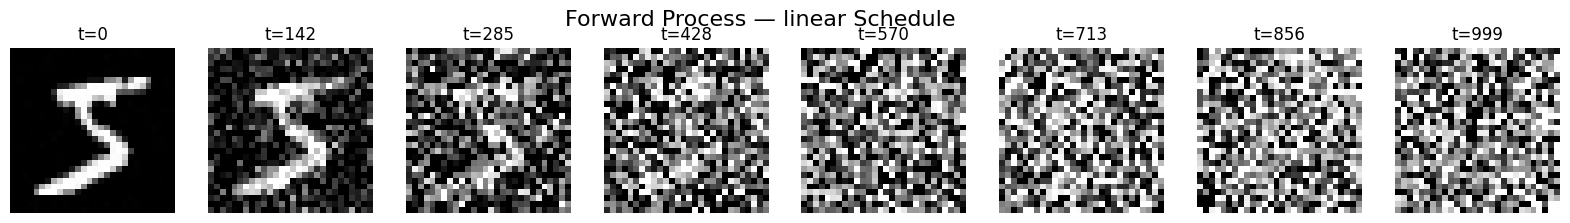

Training with scaled_linear schedule


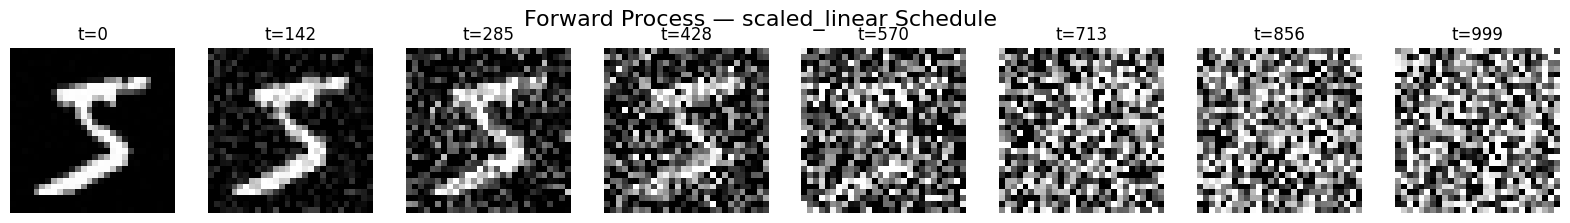

Training with squaredcos_cap_v2 schedule


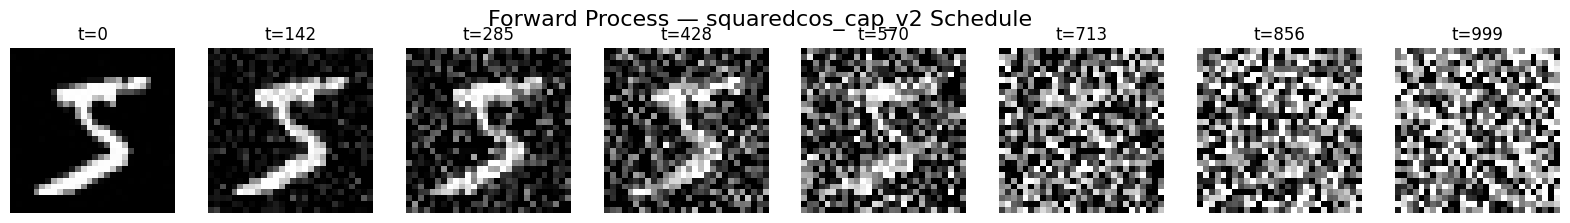

Training with sigmoid schedule


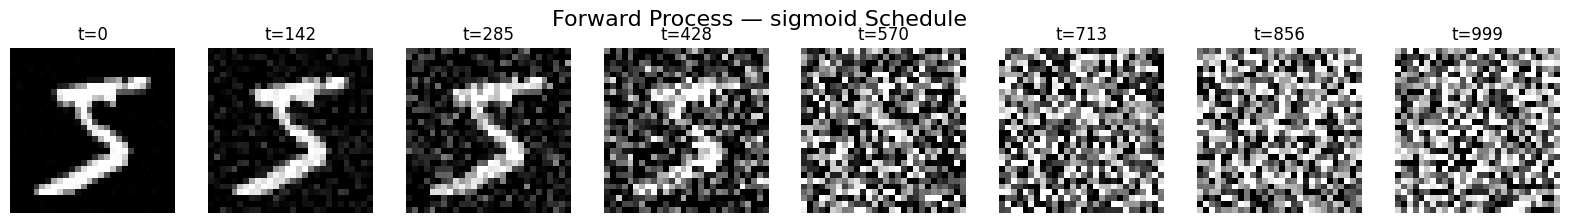

In [ ]:
for schedule in beta_schedules:
  print(f"Training with {schedule} schedule")
  scheduler_kwargs = {
        "beta_schedule": schedule,
        "num_train_timesteps": 1000
    }
  trainer = DiffusionTrainer(device=device, scheduler_kwargs=scheduler_kwargs, lr=1e-4)
  visualize_forward_diffusion(trainer, dataset, schedule_name=trainer.noise_scheduler.config.beta_schedule, num_steps=8)

#### Generating images using different schedules

We explore each noise_schedule proposed in the library and observe how their generated samples varry after being trained on 5 epochs.

Training with linear schedule


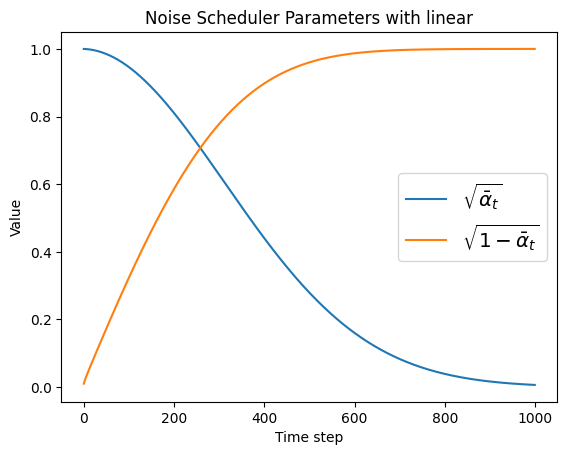

Epoch 1/10, Avg Loss: 0.09954
Epoch 2/10, Avg Loss: 0.04052
Epoch 3/10, Avg Loss: 0.03438
Epoch 4/10, Avg Loss: 0.03171
Epoch 5/10, Avg Loss: 0.02983
Epoch 6/10, Avg Loss: 0.02878
Epoch 7/10, Avg Loss: 0.02778
Epoch 8/10, Avg Loss: 0.02693
Epoch 9/10, Avg Loss: 0.02646
Epoch 10/10, Avg Loss: 0.02572


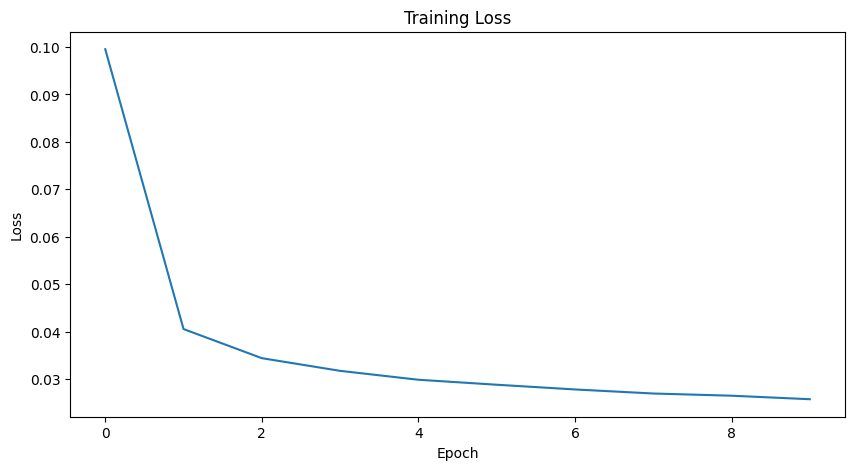

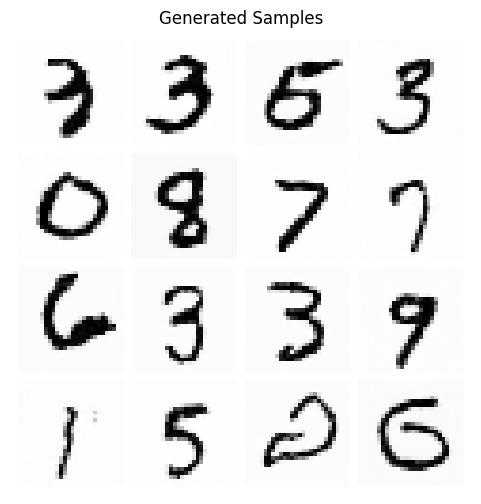

Training with scaled_linear schedule


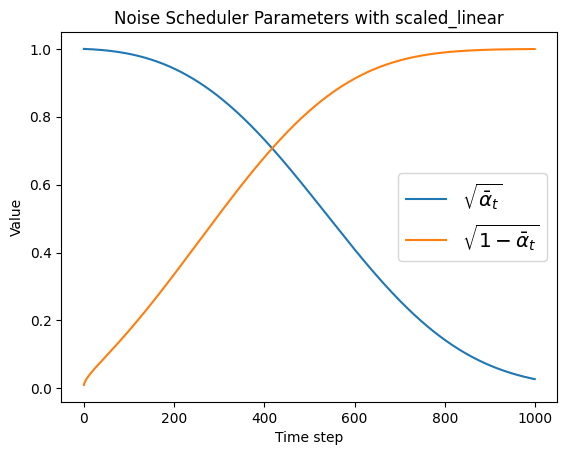

Epoch 1/10, Avg Loss: 0.13025
Epoch 2/10, Avg Loss: 0.05698
Epoch 3/10, Avg Loss: 0.04903
Epoch 4/10, Avg Loss: 0.04512
Epoch 5/10, Avg Loss: 0.04326
Epoch 6/10, Avg Loss: 0.04147
Epoch 7/10, Avg Loss: 0.04012
Epoch 8/10, Avg Loss: 0.03958
Epoch 9/10, Avg Loss: 0.03869
Epoch 10/10, Avg Loss: 0.03787


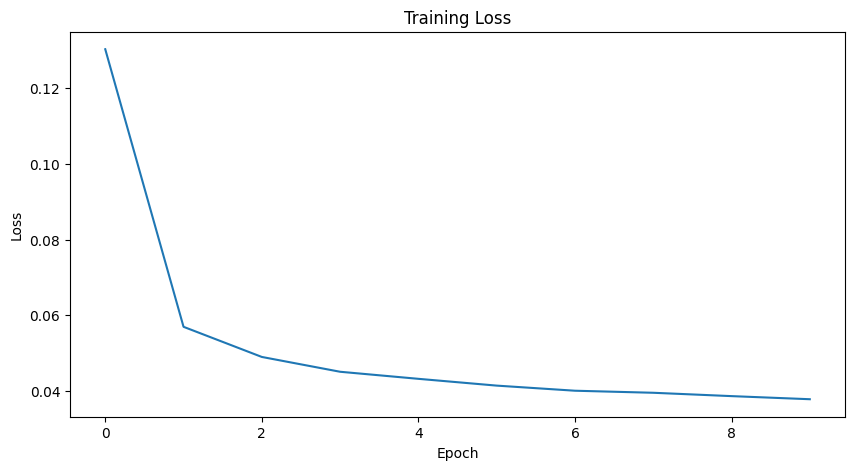

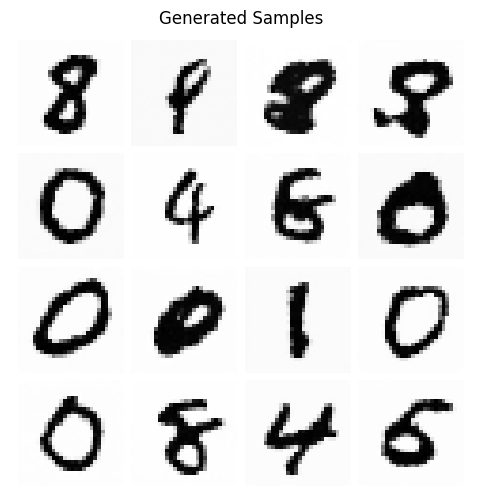

Training with squaredcos_cap_v2 schedule


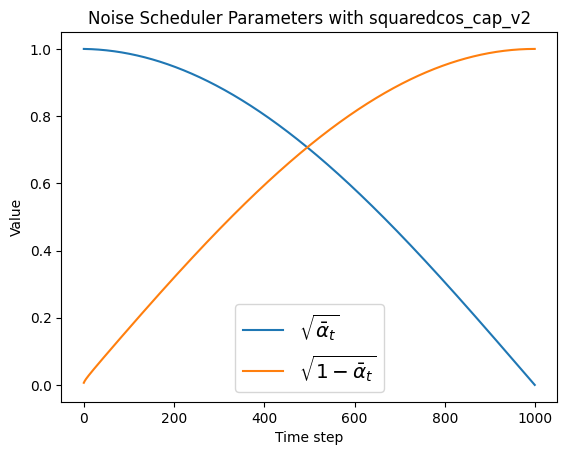

Epoch 1/10, Avg Loss: 0.12945
Epoch 2/10, Avg Loss: 0.06253
Epoch 3/10, Avg Loss: 0.05449
Epoch 4/10, Avg Loss: 0.05093
Epoch 5/10, Avg Loss: 0.04835
Epoch 6/10, Avg Loss: 0.04686
Epoch 7/10, Avg Loss: 0.04568
Epoch 8/10, Avg Loss: 0.04516
Epoch 9/10, Avg Loss: 0.04409
Epoch 10/10, Avg Loss: 0.04369


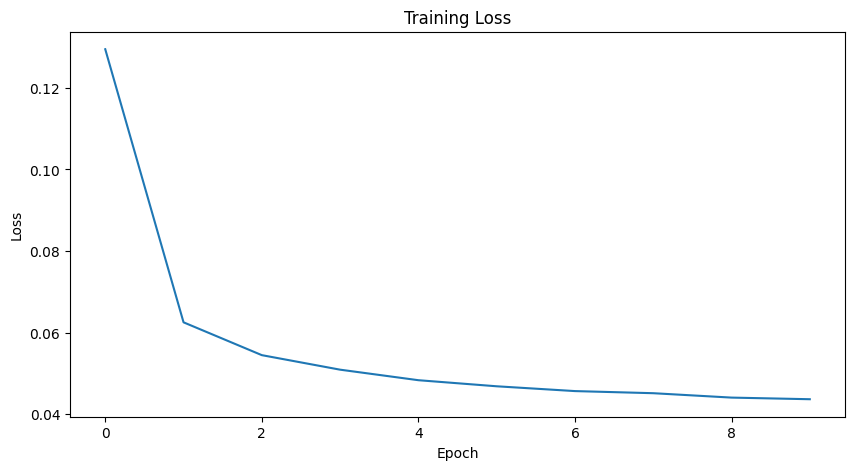

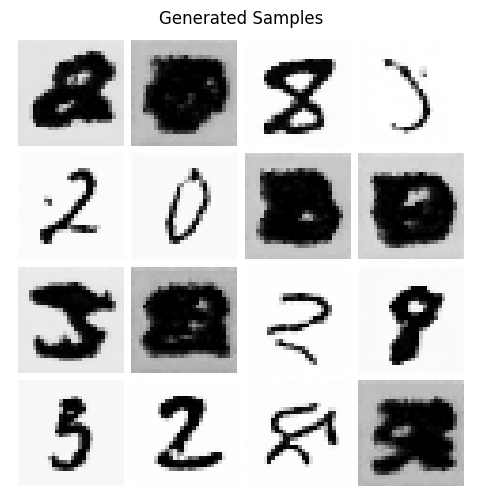

Training with sigmoid schedule


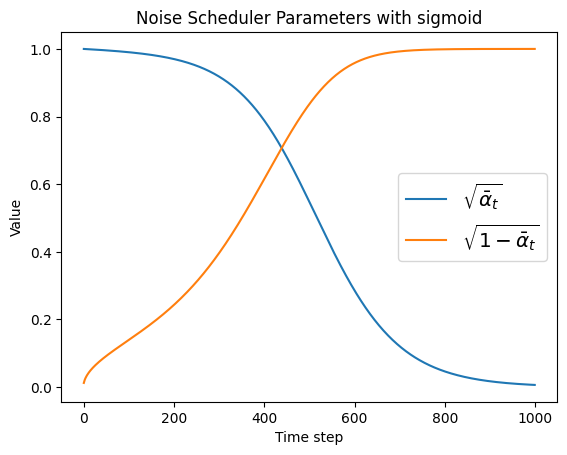

Epoch 1/10, Avg Loss: 0.13161
Epoch 2/10, Avg Loss: 0.05814
Epoch 3/10, Avg Loss: 0.05029
Epoch 4/10, Avg Loss: 0.04640
Epoch 5/10, Avg Loss: 0.04385
Epoch 6/10, Avg Loss: 0.04271
Epoch 7/10, Avg Loss: 0.04156
Epoch 8/10, Avg Loss: 0.04106
Epoch 9/10, Avg Loss: 0.04028
Epoch 10/10, Avg Loss: 0.03944


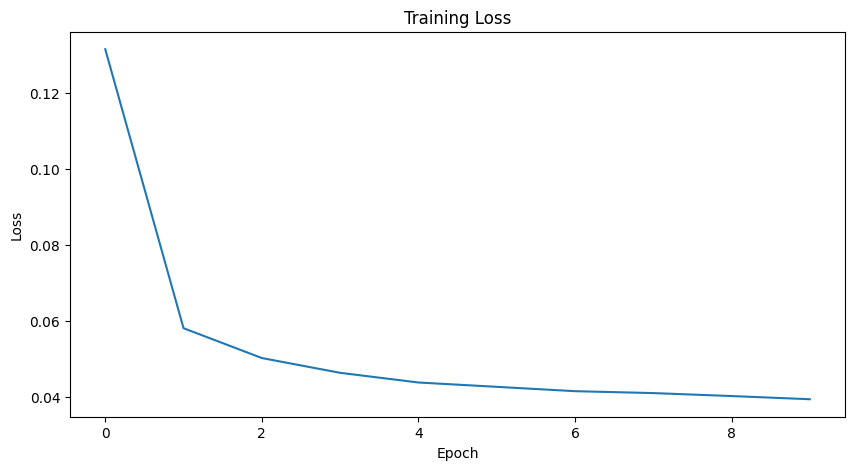

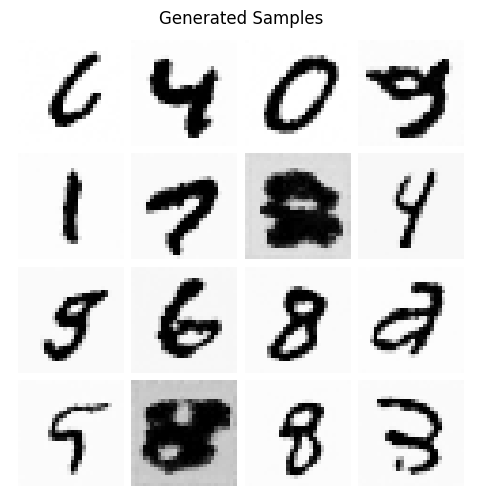

In [ ]:
for schedule in beta_schedules:
    print(f"Training with {schedule} schedule")

    scheduler_kwargs = {
        "beta_schedule": schedule,
        "num_train_timesteps": 1000
    }

    plot_noise(scheduler_kwargs)

    trainer = DiffusionTrainer(device=device, scheduler_kwargs=scheduler_kwargs, lr=1e-4)

    trainer.train(train_dataloader, epochs=10)

    plot_generated_samples(trainer.sample(num_samples=16), title=f"Generated Samples with {schedule} schedule")


We can conclude that the linear schedule seem to be performing best together with the scaled linear, followed by the sigmoid scheduling that still achieves quite a high performance. Finally, the cosine schedule seems to be poorly performing in this generative task.

### Hyperparameter tuning

We run Optuna three times on the tuning of the noise shceudling parameters to ensure a coherence in the results.

#### Trial 1

In [ ]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)
torch.save(
                study.best_params,
                f"ddpm_best_parameters_20trials_1.pt"
            )
print("Best hyperparameters:", study.best_params)


[I 2025-06-11 09:12:55,827] A new study created in memory with name: no-name-e324a676-6533-42e0-906f-d281de14b48c
[I 2025-06-11 09:12:58,602] Trial 0 finished with value: 0.6592450548302043 and parameters: {'beta_schedule': 'scaled_linear', 'beta_start': 1.7797665932979952e-05, 'beta_end': 0.17413091928873645, 'lr': 8.34227853879134e-05}. Best is trial 0 with value: 0.6592450548302043.
[I 2025-06-11 09:13:01,280] Trial 1 finished with value: 0.5103734948418357 and parameters: {'beta_schedule': 'squaredcos_cap_v2', 'beta_start': 5.630036903395285e-05, 'beta_end': 0.03358544225025683, 'lr': 0.00034573014266381553}. Best is trial 1 with value: 0.5103734948418357.
[I 2025-06-11 09:13:03,957] Trial 2 finished with value: 0.7771231694654985 and parameters: {'beta_schedule': 'squaredcos_cap_v2', 'beta_start': 4.414323999213937e-05, 'beta_end': 0.1900080764031169, 'lr': 8.07554261958275e-05}. Best is trial 1 with value: 0.5103734948418357.
[I 2025-06-11 09:13:06,636] Trial 3 finished with valu

Best hyperparameters: {'beta_schedule': 'sigmoid', 'beta_start': 0.0008315535113787333, 'beta_end': 0.08597532538679128, 'lr': 0.0009586196980257175}


In [53]:
file_path = "Hyperparameter tuning/Trial 1/ddpm_best_parameters_20trials_1.pt"

best_params = torch.load(file_path)

print("Best parameters:", best_params)


Best parameters: {'beta_schedule': 'sigmoid', 'beta_start': 0.0008315535113787333, 'beta_end': 0.08597532538679128, 'lr': 0.0009586196980257175}


#### Generating images with set hyperparameter

Epoch 1/10, Avg Loss: 0.04433
Epoch 2/10, Avg Loss: 0.02555
Epoch 3/10, Avg Loss: 0.02293
Epoch 4/10, Avg Loss: 0.02172
Epoch 5/10, Avg Loss: 0.02091
Epoch 6/10, Avg Loss: 0.02050
Epoch 7/10, Avg Loss: 0.02023
Epoch 8/10, Avg Loss: 0.01995
Epoch 9/10, Avg Loss: 0.01966
Epoch 10/10, Avg Loss: 0.01960


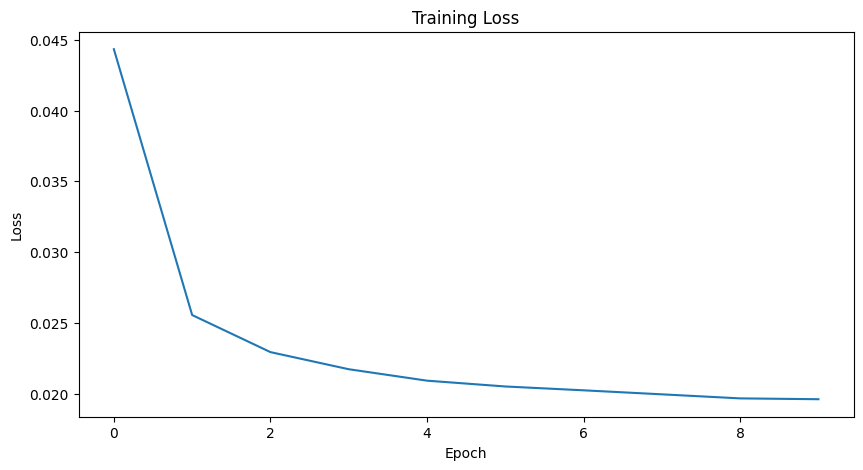

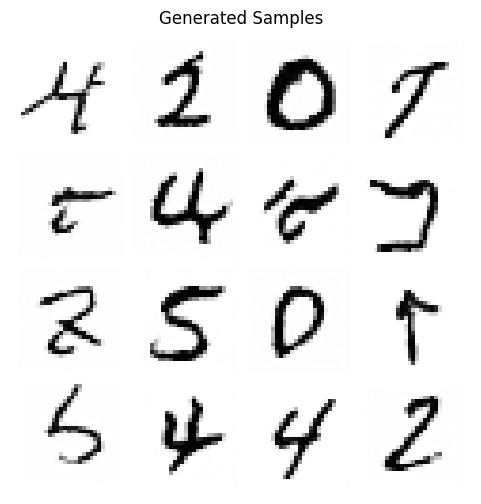

In [ ]:

trainer = DiffusionTrainer(device=device, scheduler_kwargs={
    "beta_schedule": best_params["beta_schedule"],
    "beta_start": best_params["beta_start"],
    "beta_end": best_params["beta_end"],
    "num_train_timesteps": 1000
}, lr=best_params["lr"])

trainer.train(train_dataloader, epochs=10)

samples = trainer.sample(num_samples=16)
grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)

plt.figure(figsize=(6, 6))
plt.title("Generated Samples")
plt.imshow(grid[0], cmap='Greys')
plt.axis('off')
plt.show()


#### Trial 2

In [ ]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)
torch.save(
                study.best_params,
                f"ddpm_best_parameters_20trials_2.pt"
            )
print("Best hyperparameters:", study.best_params)


[I 2025-06-11 09:49:34,718] A new study created in memory with name: no-name-e7282642-9252-403d-8274-e6e47b3d9fac
[I 2025-06-11 09:49:37,511] Trial 0 finished with value: 0.37662084671584045 and parameters: {'beta_schedule': 'squaredcos_cap_v2', 'beta_start': 0.00023014546722509212, 'beta_end': 0.031519286191077384, 'lr': 0.0008957284554959903}. Best is trial 0 with value: 0.37662084671584045.
[I 2025-06-11 09:49:40,215] Trial 1 finished with value: 0.910457042130557 and parameters: {'beta_schedule': 'sigmoid', 'beta_start': 8.873911466748473e-05, 'beta_end': 0.18218978981837944, 'lr': 2.7908621327058428e-05}. Best is trial 0 with value: 0.37662084671584045.
[I 2025-06-11 09:49:43,331] Trial 2 finished with value: 0.967000354420055 and parameters: {'beta_schedule': 'sigmoid', 'beta_start': 1.3600461929700901e-05, 'beta_end': 0.06945583104921228, 'lr': 2.3066005598014445e-05}. Best is trial 0 with value: 0.37662084671584045.
[I 2025-06-11 09:49:46,066] Trial 3 finished with value: 0.891

Best hyperparameters: {'beta_schedule': 'linear', 'beta_start': 0.00026165575579022095, 'beta_end': 0.016269379978580373, 'lr': 0.0009348624195736696}


In [52]:
file_path = "Hyperparameter tuning/Trial 2/ddpm_best_parameters_20trials_2.pt"

best_params = torch.load(file_path)

print("Best parameters:", best_params)


Best parameters: {'beta_schedule': 'linear', 'beta_start': 0.00026165575579022095, 'beta_end': 0.016269379978580373, 'lr': 0.0009348624195736696}


Best hyperparameters: {'beta_schedule': 'linear', 'beta_start': 0.00026165575579022095, 'beta_end': 0.016269379978580373, 'lr': 0.0009348624195736696}
Epoch 1/10, Avg Loss: 0.04888
Epoch 2/10, Avg Loss: 0.03040
Epoch 3/10, Avg Loss: 0.02825
Epoch 4/10, Avg Loss: 0.02680
Epoch 5/10, Avg Loss: 0.02593
Epoch 6/10, Avg Loss: 0.02519
Epoch 7/10, Avg Loss: 0.02488
Epoch 8/10, Avg Loss: 0.02456
Epoch 9/10, Avg Loss: 0.02434
Epoch 10/10, Avg Loss: 0.02436


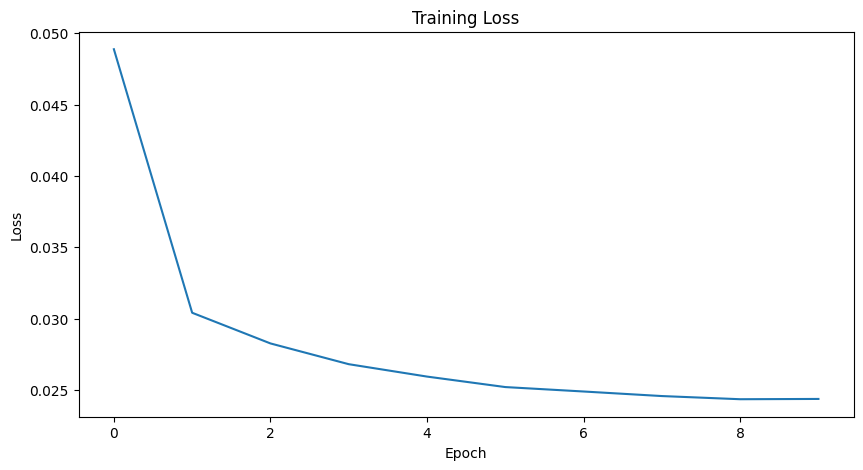

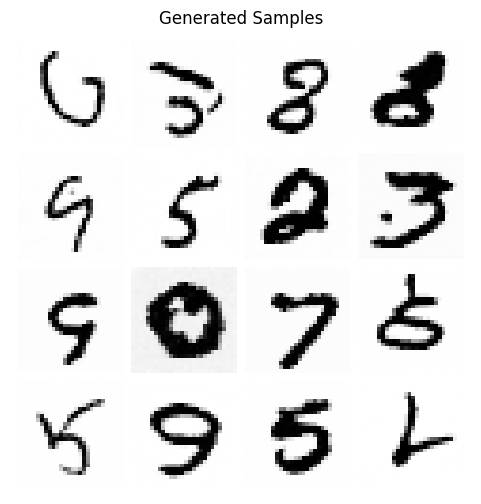

In [ ]:
trainer = DiffusionTrainer(device=device, scheduler_kwargs={
    "beta_schedule": best_params["beta_schedule"],
    "beta_start": best_params["beta_start"],
    "beta_end": best_params["beta_end"],
    "num_train_timesteps": 1000
}, lr=best_params["lr"])
print("Best hyperparameters:", best_params)

trainer.train(train_dataloader, epochs=10)

samples = trainer.sample(num_samples=16)
grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)

plt.figure(figsize=(6, 6))
plt.title("Generated Samples")
plt.imshow(grid[0], cmap='Greys')
plt.axis('off')
plt.show()


#### Trial 3

In [ ]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)
torch.save(
                study.best_params,
                f"ddpm_best_parameters_20trials_3.pt"
            )
print("Best hyperparameters:", study.best_params)


[I 2025-06-11 11:39:59,805] A new study created in memory with name: no-name-71be0b8b-22ed-4913-b03d-33f54ee09dcd
[I 2025-06-11 11:40:02,582] Trial 0 finished with value: 0.8897022279826078 and parameters: {'beta_schedule': 'squaredcos_cap_v2', 'beta_start': 0.0005581585509214024, 'beta_end': 0.0527656463907613, 'lr': 2.704189608567875e-05}. Best is trial 0 with value: 0.8897022279826078.
[I 2025-06-11 11:40:05,273] Trial 1 finished with value: 1.018346602266485 and parameters: {'beta_schedule': 'squaredcos_cap_v2', 'beta_start': 2.2870549236943736e-05, 'beta_end': 0.1567659169172229, 'lr': 4.644232887277462e-05}. Best is trial 0 with value: 0.8897022279826078.
[I 2025-06-11 11:40:07,954] Trial 2 finished with value: 0.9325768514112993 and parameters: {'beta_schedule': 'scaled_linear', 'beta_start': 2.5841114341857155e-05, 'beta_end': 0.1953094873957609, 'lr': 3.970064359375515e-05}. Best is trial 0 with value: 0.8897022279826078.
[I 2025-06-11 11:40:10,618] Trial 3 finished with value

Best hyperparameters: {'beta_schedule': 'linear', 'beta_start': 1.2750779510318114e-05, 'beta_end': 0.05027043614958262, 'lr': 0.0009463026914857639}


In [51]:
file_path = "Hyperparameter tuning/Trial 3/ddpm_best_parameters_20trials_3.pt"

best_params = torch.load(file_path)

print("Best parameters:", best_params)


Best parameters: {'beta_schedule': 'linear', 'beta_start': 1.2750779510318114e-05, 'beta_end': 0.05027043614958262, 'lr': 0.0009463026914857639}


Best hyperparameters: {'beta_schedule': 'linear', 'beta_start': 1.2750779510318114e-05, 'beta_end': 0.05027043614958262, 'lr': 0.0009463026914857639}
Epoch 1/10, Avg Loss: 0.04012
Epoch 2/10, Avg Loss: 0.02207
Epoch 3/10, Avg Loss: 0.01983
Epoch 4/10, Avg Loss: 0.01814
Epoch 5/10, Avg Loss: 0.01746
Epoch 6/10, Avg Loss: 0.01720
Epoch 7/10, Avg Loss: 0.01676
Epoch 8/10, Avg Loss: 0.01635
Epoch 9/10, Avg Loss: 0.01617
Epoch 10/10, Avg Loss: 0.01613


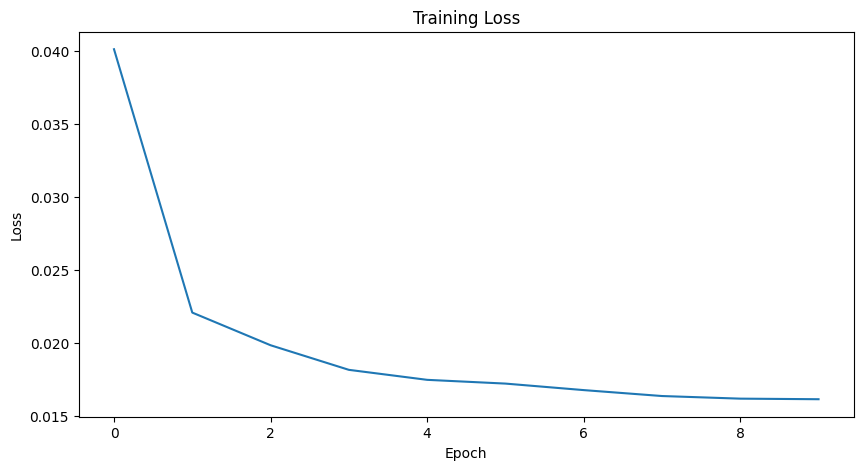

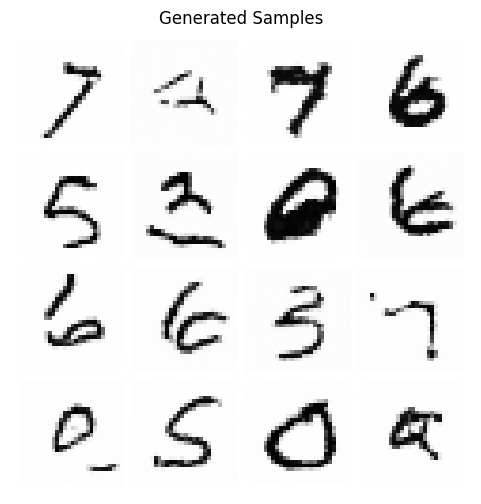

In [ ]:
trainer = DiffusionTrainer(device=device, scheduler_kwargs={
    "beta_schedule": best_params["beta_schedule"],
    "beta_start": best_params["beta_start"],
    "beta_end": best_params["beta_end"],
    "num_train_timesteps": 1000
}, lr=best_params["lr"])
print("Best hyperparameters:", best_params)

trainer.train(train_dataloader, epochs=10)

samples = trainer.sample(num_samples=16)
grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)

plt.figure(figsize=(6, 6))
plt.title("Generated Samples")
plt.imshow(grid[0], cmap='Greys')
plt.axis('off')
plt.show()


In [43]:
file_path = "Hyperparameter tuning/Trial 3/ddpm_best_parameters_20trials_3.pt"

best_params = torch.load(file_path)

print("Best parameters:", best_params)

Best parameters: {'beta_schedule': 'linear', 'beta_start': 1.2750779510318114e-05, 'beta_end': 0.05027043614958262, 'lr': 0.0009463026914857639}


No finally conclusions can be drawn regarding the noise scheduling optimal parameters, different optimal parameters are retrieved each time. We however explore the impact of a longer training on the best-performing model recovered above.

Best hyperparameters: {'beta_schedule': 'linear', 'beta_start': 1.2750779510318114e-05, 'beta_end': 0.05027043614958262, 'lr': 0.0009463026914857639}


/usr/local/lib/python3.11/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch 1/20, Avg Loss: 0.03753
Epoch 2/20, Avg Loss: 0.02159
Epoch 3/20, Avg Loss: 0.01955
Epoch 4/20, Avg Loss: 0.01821
Epoch 5/20, Avg Loss: 0.01751
Epoch 6/20, Avg Loss: 0.01733
Epoch 7/20, Avg Loss: 0.01656
Epoch 8/20, Avg Loss: 0.01637
Epoch 9/20, Avg Loss: 0.01607
Epoch 10/20, Avg Loss: 0.01593
Epoch 11/20, Avg Loss: 0.01585
Epoch 12/20, Avg Loss: 0.01565
Epoch 13/20, Avg Loss: 0.01552
Epoch 14/20, Avg Loss: 0.01545
Epoch 15/20, Avg Loss: 0.01538
Epoch 16/20, Avg Loss: 0.01550
Epoch 17/20, Avg Loss: 0.01508
Epoch 18/20, Avg Loss: 0.01543
Epoch 19/20, Avg Loss: 0.01517
Epoch 20/20, Avg Loss: 0.01494


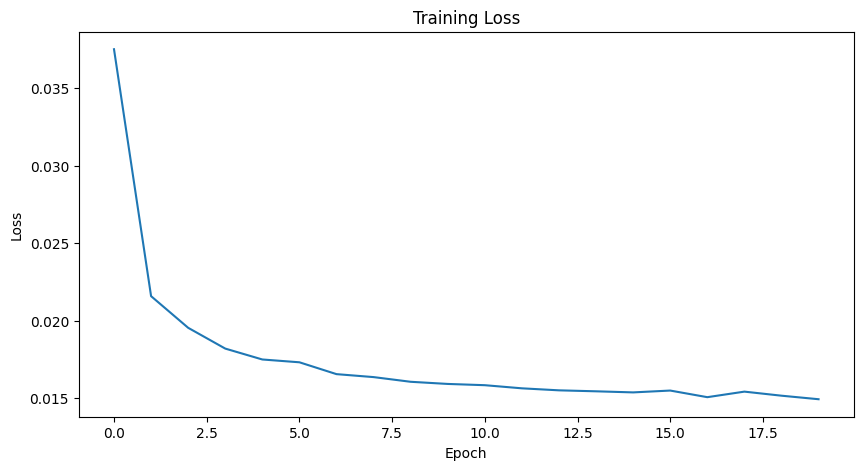

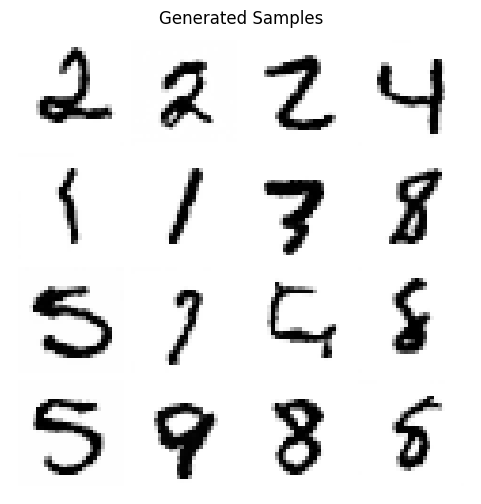

In [45]:
trainer = DiffusionTrainer(device=device, scheduler_kwargs={
    "beta_schedule": best_params["beta_schedule"],
    "beta_start": best_params["beta_start"],
    "beta_end": best_params["beta_end"],
    "num_train_timesteps": 1000
}, lr=best_params["lr"])
print("Best hyperparameters:", best_params)

trainer.train(train_dataloader, epochs=20)

samples = trainer.sample(num_samples=16)
grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)

plt.figure(figsize=(6, 6))
plt.title("Generated Samples")
plt.imshow(grid[0], cmap='Greys')
plt.axis('off')
plt.show()

Here are the final generated samples, through 20 epochs and the optimal parameters found through the Optuna optimization. They indeed have a better quality and high-fidelity to the MNIST dataset compared to the previous ones.